## Задача: Прогнозирование риска развития диабета 2 типа

Вы работаете специалистом по анализу данных в крупной исследовательской клинике. Ваша задача — разработать модель, которая поможет врачам оценить риск развития диабета 2 типа у пациентов на основе их анамнеза, лабораторных показателей и демографических данных. Раннее выявление группы риска позволит своевременно принять профилактические меры и улучшить качество жизни пациентов.

Вам предоставлен анонимизированный набор данных пациентов, который включает различные медицинские параметры. **Целевая переменная** — `Диабет` (Diabetes), где `1` означает подтвержденный диагноз диабета 2 типа, `0` — отсутствие диабета.

**Цель:** Создать модель логистической регрессии, которая с высокой точностью будет предсказывать риск развития диабета 2 типа.



### Описание данных:

* `ID_Пациента`: Уникальный идентификатор пациента (для удобства, не используется в модели).
* `Пол`: Пол пациента (Мужчина/Женщина).
* `Возраст`: Возраст пациента в годах.
* `ИМТ`: Индекс массы тела (BMI - Body Mass Index).
* `Глюкоза_натощак`: Уровень глюкозы в крови натощак (ммоль/л).
* `Артериальное_давление_SYS`: Систолическое артериальное давление (мм рт.ст.).
* `Артериальное_давление_DIA`: Диастолическое артериальное давление (мм рт.ст.).
* `Холестерин_ЛПНП`: Уровень холестерина липопротеинов низкой плотности (LDL-C) (ммоль/л).
* `Семейный_анамнез_диабета`: Наличие диабета в семейном анамнезе (Да/Нет).
* `Физическая_активность`: Уровень физической активности (Низкая/Средняя/Высокая).
* `Курение`: Статус курения (Не_курит/Бывший_курильщик/Курит).
* `Диабет`: Целевая переменная (0 - нет диабета, 1 - есть диабет).


Создаем демонстрационные данные для медицинского кейса.

Первые 5 строк данных:
   ID_Пациента      Пол  Возраст        ИМТ  Глюкоза_натощак  \
0            1  Мужчина       78  44.668505        10.976446   
1            2  Женщина       41  29.549875        10.899917   
2            3  Мужчина       33  28.376819         5.529768   
3            4  Мужчина       57  36.350477         7.335534   
4            5  Мужчина       77  23.892855        11.872412   
5            6  Женщина       44  43.648952        10.062106   
6            7  Мужчина       37  39.231315         3.730923   
7            8  Мужчина       52  20.414097         4.054239   
8            9  Мужчина       72  29.274681         7.443417   
9           10  Женщина       53  41.736194        11.228372   

   Артериальное_давление_SYS  Артериальное_давление_DIA  Холестерин_ЛПНП  \
0                 143.790145                  94.126623         4.903615   
1                 167.948607                  88.767959        

<ipython-input-4-2915592492>:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


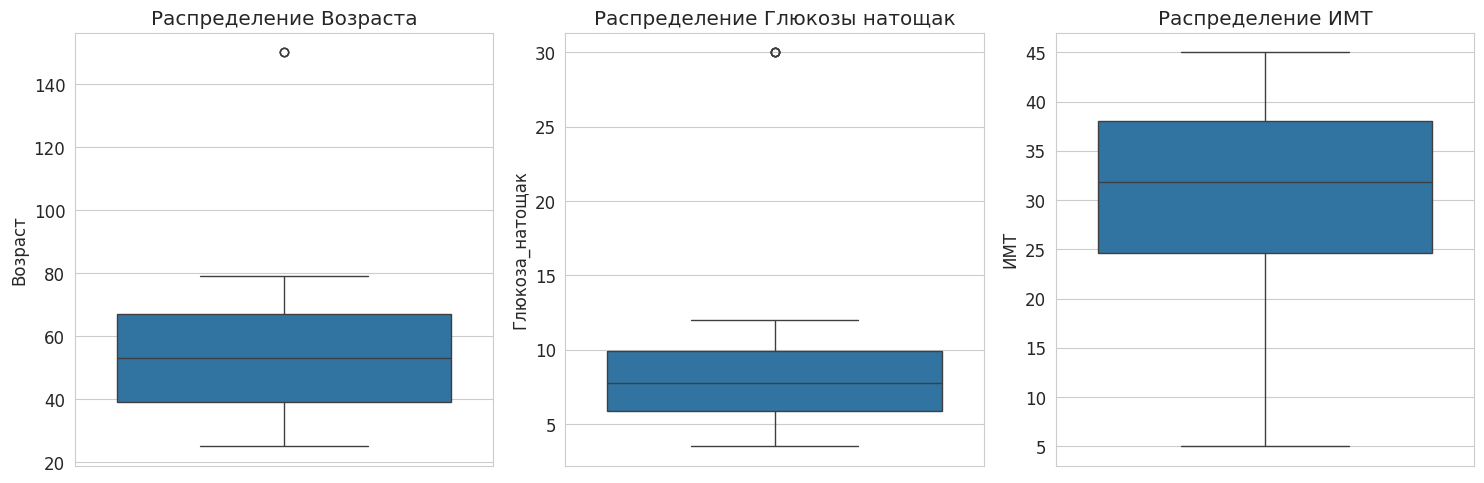

Глюкоза_натощак ограничена на уровне 99.5-го перцентиля: 12.07

Статистика некоторых признаков после обработки выбросов:
           Возраст          ИМТ  Глюкоза_натощак  Артериальное_давление_SYS
count  1000.000000  1000.000000      1000.000000                1000.000000
mean     52.626000    31.522355         7.786766                 134.425828
std      16.211753     7.815338         2.443136                  26.072589
min      25.000000    10.000000         3.500099                  70.000000
25%      39.000000    24.638753         5.851869                 111.594182
50%      53.000000    31.792195         7.753410                 134.004968
75%      67.000000    38.058488         9.909285                 157.390444
max     100.000000    44.984171        12.071570                 179.960193


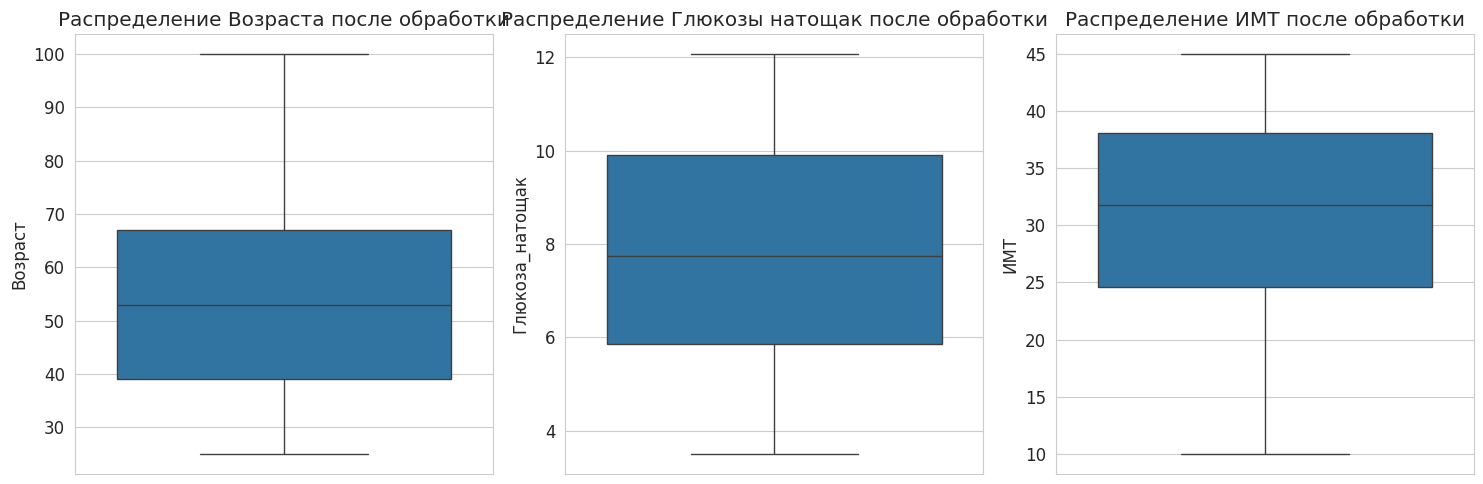


Категориальные признаки: ['Пол', 'Семейный_анамнез_диабета', 'Физическая_активность', 'Курение']
Числовые признаки: ['Возраст', 'ИМТ', 'Глюкоза_натощак', 'Артериальное_давление_SYS', 'Артериальное_давление_DIA', 'Холестерин_ЛПНП']

Размер X_train до кодирования и масштабирования: (750, 10)
Размер X_train после кодирования и масштабирования: (750, 14)

Первые 5 строк X_train после кодирования и масштабирования:
    Возраст       ИМТ  Глюкоза_натощак  Артериальное_давление_SYS  \
0 -0.404729  1.608180        -0.778773                  -0.286216   
1  1.140195  1.000048         0.885968                  -1.344383   
2  0.151444 -0.322698        -1.200205                  -1.409346   
3  1.140195 -0.138204         1.667556                  -1.648624   
4  0.275038 -1.113585         0.820788                  -0.812958   

   Артериальное_давление_DIA  Холестерин_ЛПНП  Пол_Женщина  Пол_Мужчина  \
0                   0.595082        -0.306923          0.0          1.0   
1                   

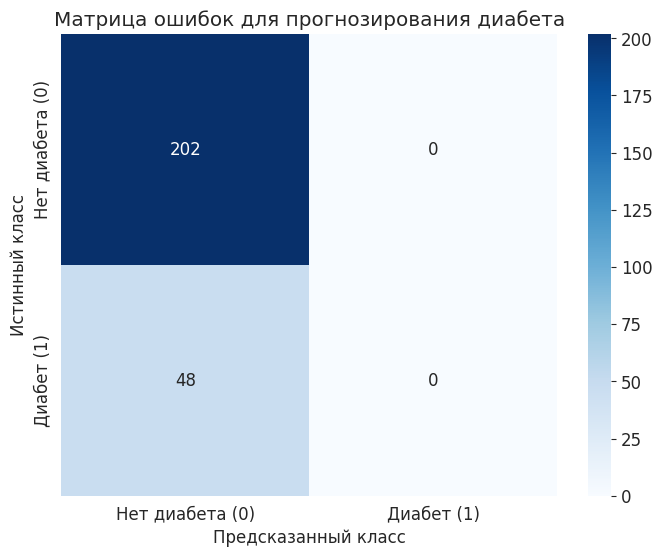


Отчет по классификации:
              precision    recall  f1-score   support

           0       0.81      1.00      0.89       202
           1       0.00      0.00      0.00        48

    accuracy                           0.81       250
   macro avg       0.40      0.50      0.45       250
weighted avg       0.65      0.81      0.72       250



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


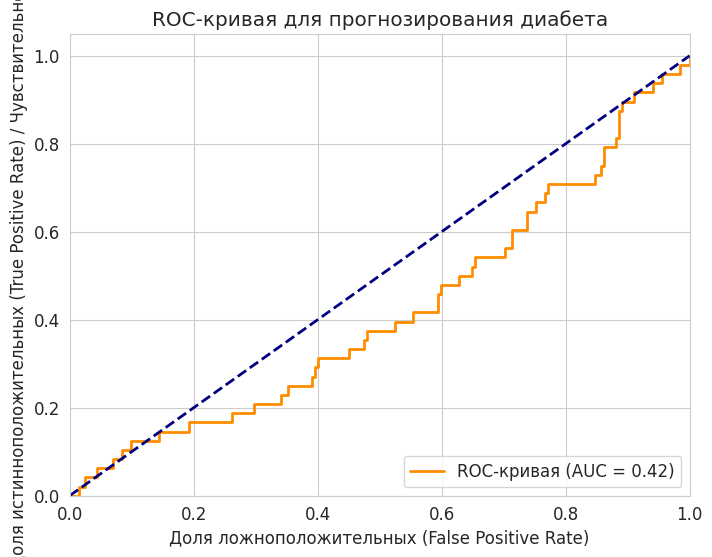

AUC-ROC на тестовом наборе: 0.4196

Коэффициенты логистической регрессии (в порядке убывания важности):
                        Признак  Коэффициент  Абс_Коэффициент
5  Семейный_анамнез_диабета_Нет    -0.458122         0.458122
2                   Пол_Женщина    -0.393455         0.393455
3                   Пол_Мужчина    -0.292916         0.292916
4   Семейный_анамнез_диабета_Да    -0.228250         0.228250
0     Артериальное_давление_DIA     0.179752         0.179752
1               Холестерин_ЛПНП     0.137320         0.137320
6                 Курение_Курит    -0.125191         0.125191


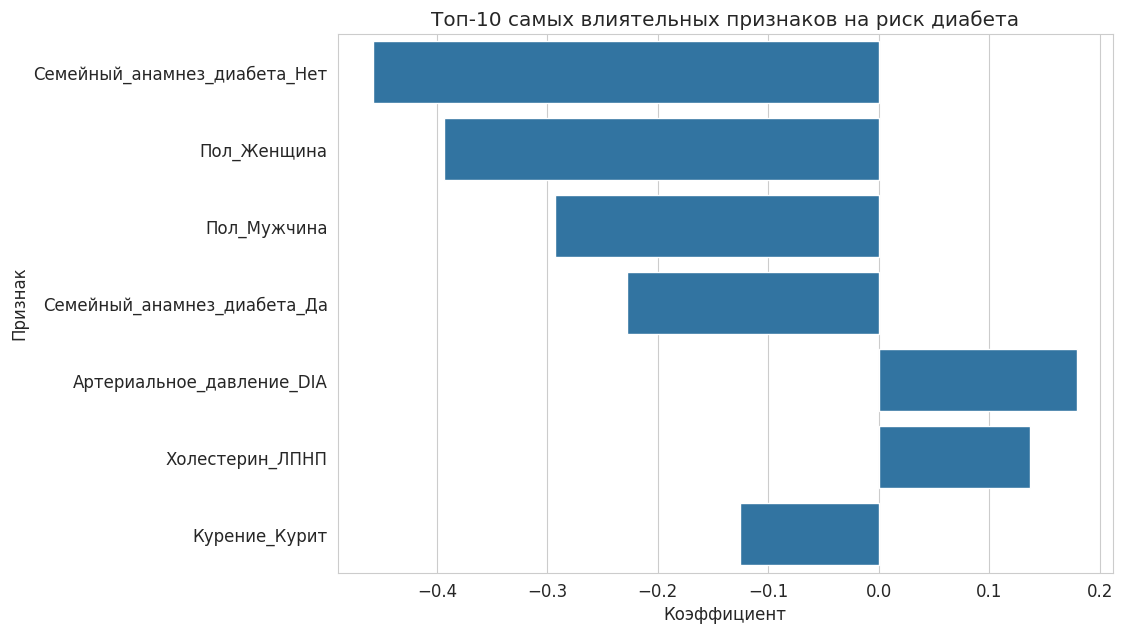

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Настройка стиля для графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# 1. Загрузка данных (создаем синтетические данные для демонстрации)
print("Создаем демонстрационные данные для медицинского кейса.")
np.random.seed(42) # Для воспроизводимости

data = {
    'ID_Пациента': range(1, 1001),
    'Пол': np.random.choice(['Мужчина', 'Женщина'], 1000),
    'Возраст': np.random.randint(25, 80, 1000),
    'ИМТ': np.random.uniform(18.0, 45.0, 1000),
    'Глюкоза_натощак': np.random.uniform(3.5, 12.0, 1000), # Норма 3.3 - 5.5, повышенная до 7, диабет > 7
    'Артериальное_давление_SYS': np.random.uniform(90, 180, 1000),
    'Артериальное_давление_DIA': np.random.uniform(60, 110, 1000),
    'Холестерин_ЛПНП': np.random.uniform(1.5, 5.0, 1000), # Норма до 3.0
    'Семейный_анамнез_диабета': np.random.choice(['Да', 'Нет'], 1000, p=[0.3, 0.7]),
    'Физическая_активность': np.random.choice(['Низкая', 'Средняя', 'Высокая'], 1000, p=[0.25, 0.5, 0.25]),
    'Курение': np.random.choice(['Не_курит', 'Бывший_курильщик', 'Курит'], 1000, p=[0.6, 0.2, 0.2]),
    'Диабет': np.random.choice([0, 1], 1000, p=[0.8, 0.2]) # 20% случаев диабета
}

df = pd.DataFrame(data)

# Вводим пропущенные значения и выбросы для демонстрации
for col in ['ИМТ', 'Глюкоза_натощак', 'Холестерин_ЛПНП']:
    df.loc[np.random.choice(df.index, 25, replace=False), col] = np.nan # 2.5% пропусков

# Добавляем аномальные значения
df.loc[np.random.choice(df.index, 3, replace=False), 'Возраст'] = 150 # Выброс
df.loc[np.random.choice(df.index, 5, replace=False), 'Глюкоза_натощак'] = 30.0 # Очень высокий выброс
df.loc[np.random.choice(df.index, 2, replace=False), 'ИМТ'] = 5.0 # Недостаточный ИМТ (ошибка)
df.loc[np.random.choice(df.index, 2, replace=False), 'Артериальное_давление_SYS'] = 50 # Низкое давление

print("\nПервые 5 строк данных:")
print(df.head(10))
print("\nИнформация о данных:")
df.info()

print("\nПропущенные значения до обработки:")
print(df.isnull().sum())

# Заполнение пропущенных числовых значений медианой
for col in ['ИМТ', 'Глюкоза_натощак', 'Холестерин_ЛПНП']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Пропущенные значения в '{col}' заполнены медианой: {median_val:.2f}")

print("\nПропущенные значения после обработки:")
print(df.isnull().sum())

print("\nСтатистика некоторых признаков до обработки выбросов:")
print(df[['Возраст', 'ИМТ', 'Глюкоза_натощак', 'Артериальное_давление_SYS']].describe())

# Визуализация выбросов с помощью boxplot
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Возраст'])
plt.title('Распределение Возраста')
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Глюкоза_натощак'])
plt.title('Распределение Глюкозы натощак')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['ИМТ'])
plt.title('Распределение ИМТ')
plt.tight_layout()
plt.show()

# Ограничение значений (Winsorization/Clipping)
# Возраст: разумный диапазон 0-100
df['Возраст'] = df['Возраст'].clip(lower=0, upper=100)
# ИМТ: разумный диапазон 10-60 (очень низкий/высокий, но не 5)
df['ИМТ'] = df['ИМТ'].clip(lower=10, upper=60)
# Глюкоза_натощак: ограничим верхний хвост, например, 99.5-м перцентилем
q_99_5_glucose = df['Глюкоза_натощак'].quantile(0.995)
df['Глюкоза_натощак'] = df['Глюкоза_натощак'].clip(upper=q_99_5_glucose)
print(f"Глюкоза_натощак ограничена на уровне 99.5-го перцентиля: {q_99_5_glucose:.2f}")

# Артериальное давление: разумные медицинские пределы
df['Артериальное_давление_SYS'] = df['Артериальное_давление_SYS'].clip(lower=70, upper=220)
df['Артериальное_давление_DIA'] = df['Артериальное_давление_DIA'].clip(lower=40, upper=140)


print("\nСтатистика некоторых признаков после обработки выбросов:")
print(df[['Возраст', 'ИМТ', 'Глюкоза_натощак', 'Артериальное_давление_SYS']].describe())

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Возраст'])
plt.title('Распределение Возраста после обработки')
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Глюкоза_натощак'])
plt.title('Распределение Глюкозы натощак после обработки')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['ИМТ'])
plt.title('Распределение ИМТ после обработки')
plt.tight_layout()
plt.show()

# Разделение на признаки (X) и целевую переменную (y)
X = df.drop(['ID_Пациента', 'Диабет'], axis=1)
y = df['Диабет']

# Определяем категориальные и числовые признаки
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=np.number).columns

print(f"\nКатегориальные признаки: {list(categorical_features)}")
print(f"Числовые признаки: {list(numerical_features)}")

# Определяем порядковый признак и его порядок
ordinal_feature = ['Физическая_активность']
# Порядок: Низкая < Средняя < Высокая
activity_order = ['Низкая', 'Средняя', 'Высокая']

# Номинальные признаки (все остальные категориальные)
nominal_features = [col for col in categorical_features if col not in ordinal_feature]

# Создаем препроцессоры для числовых и категориальных данных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # Масштабирование числовых
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features), # OHE для номинальных
        ('cat_ordinal', OrdinalEncoder(categories=[activity_order]), ordinal_feature) # Ordinal для порядковых
    ],
    remainder='passthrough' # Оставить другие колонки как есть (если есть, например, ID_Пациента, но мы его удалили)
)

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"\nРазмер X_train до кодирования и масштабирования: {X_train.shape}")

# Применяем препроцессор
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Размер X_train после кодирования и масштабирования: {X_train_processed.shape}")

# Получаем имена признаков после One-Hot Encoding
ohe_feature_names = preprocessor.named_transformers_['cat_onehot'].get_feature_names_out(nominal_features)
ordinal_feature_name_processed = [f"{col}_Encoded" for col in ordinal_feature] # Для OrdinalEncoder

# Объединяем все имена признаков
processed_feature_names = list(numerical_features) + list(ohe_feature_names) + list(ordinal_feature_name_processed)

# Преобразуем обратно в DataFrame для удобства отбора признаков
X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=processed_feature_names)

print("\nПервые 5 строк X_train после кодирования и масштабирования:")
print(X_train_processed_df.head())

# Инициализируем модель логистической регрессии для RFE
model_for_rfe = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Инициализируем RFE с 10 признаками
rfe_selector = RFE(estimator=model_for_rfe, n_features_to_select=7, step=1)

# Применяем RFE к предобработанным обучающим данным
rfe_selector.fit(X_train_processed_df, y_train)

# Получаем выбранные признаки
selected_features_rfe = X_train_processed_df.columns[rfe_selector.support_]
print(f"\nПризнаки, отобранные с помощью RFE ({len(selected_features_rfe)}):")
print(list(selected_features_rfe))

# Ограничиваем наши данные только выбранными признаками
X_train_selected = X_train_processed_df[selected_features_rfe]
X_test_selected = X_test_processed_df[selected_features_rfe]

print(f"\nРазмер X_train после отбора признаков: {X_train_selected.shape}")

# Инициализируем и обучаем модель логистической регрессии на отобранных признаках
logistic_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
logistic_model.fit(X_train_selected, y_train)

print("\nМодель логистической регрессии успешно обучена.")

# Предсказания на тестовом наборе
y_pred = logistic_model.predict(X_test_selected)
y_pred_proba = logistic_model.predict_proba(X_test_selected)[:, 1] # Вероятности для ROC-кривой

# Оценка производительности
accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность модели на тестовом наборе: {accuracy:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("\nМатрица ошибок:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет диабета (0)', 'Диабет (1)'],
            yticklabels=['Нет диабета (0)', 'Диабет (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок для прогнозирования диабета')
plt.show()

# Отчет по классификации
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred))

# ROC-кривая и AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Доля ложноположительных (False Positive Rate)')
plt.ylabel('Доля истинноположительных (True Positive Rate) / Чувствительность')
plt.title('ROC-кривая для прогнозирования диабета')
plt.legend(loc="lower right")
plt.show()

print(f"AUC-ROC на тестовом наборе: {roc_auc:.4f}")

# Коэффициенты модели (для интерпретации)
coefficients = pd.DataFrame({'Признак': X_train_selected.columns, 'Коэффициент': logistic_model.coef_[0]})
coefficients['Абс_Коэффициент'] = np.abs(coefficients['Коэффициент'])
coefficients = coefficients.sort_values(by='Абс_Коэффициент', ascending=False)
print("\nКоэффициенты логистической регрессии (в порядке убывания важности):")
print(coefficients)

plt.figure(figsize=(10, 7))
sns.barplot(x='Коэффициент', y='Признак', data=coefficients.head(10))
plt.title('Топ-10 самых влиятельных признаков на риск диабета')
plt.xlabel('Коэффициент')
plt.ylabel('Признак')
plt.show()

## Задача: Одобрение ипотечного кредита

**Контекст:**
Вы работаете консультантом по данным в небольшом, но растущем банке "Надежный Дом". Банк стремится автоматизировать процесс одобрения ипотечных кредитов, чтобы ускорить обслуживание клиентов и стандартизировать принятие решений. Ваша задача — разработать простую, но эффективную модель, которая поможет банку быстро и последовательно оценивать заявки на ипотеку и принимать решения об одобрении или отклонении.

Идеальный алгоритм для этой задачи должен быть **интерпретируемым**, то есть банк хочет не просто получить "да" или "нет", но и понять, **почему** было принято то или иное решение. Например, почему конкретному клиенту отказали, или наоборот, почему его заявка была одобрена. Это важно для объяснения клиентам, соблюдения нормативных требований и постоянного улучшения критериев одобрения.

**Деревья решений** — это идеальный выбор для такой задачи, поскольку они создают набор простых, легко понятных правил, которые можно визуализировать и объяснить.

**Целевая переменная:** `Одобрение_кредита` (0 - Отказано, 1 - Одобрено).

**Признаки (гипотетические):**

* `Возраст_заемщика`: Возраст основного заемщика.
* `Годовой_доход`: Совокупный годовой доход домохозяйства.
* `Кредитный_рейтинг`: Балл кредитного рейтинга (например, от 300 до 850).
* `Семейное_положение`: Семейное положение (Холост/Не_замужем, Женат/Замужем, В_разводе, Вдовец/Вдова).
* `Наличие_детей`: Количество несовершеннолетних детей.
* `Наличие_других_кредитов`: Есть ли у заемщика другие активные кредиты (Да/Нет).
* `Стаж_на_текущем_месте_работы_лет`: Количество лет стажа на текущей работе.
* `Тип_трудоустройства`: Тип трудоустройства (Постоянный, Временный, Свой_бизнес, Безработный).
* `Стоимость_недвижимости`: Примерная стоимость недвижимости, на которую запрашивается ипотека.
* `Первоначальный_взнос_процент`: Процент первоначального взноса от стоимости недвижимости.


### Этапы решения задачи:

1.  **Сбор и загрузка данных:** Загрузка гипотетического набора данных.
2.  **Первичный анализ данных:** Просмотр данных, проверка типов, выявление пропущенных значений.
3.  **Обработка пропущенных данных:** Заполнение или удаление пропущенных значений.
4.  **Обработка выбросов и нестандартных значений:** Коррекция явно ошибочных или экстремальных значений (например, нереалистичный возраст или доход).
5.  **Кодирование категориальных данных:** Преобразование текстовых категорий в числовой формат (например, One-Hot Encoding).
6.  **Разделение данных:** Разделение на обучающую и тестовую выборки.
7.  **Обучение модели:** Обучение модели **Дерева решений** на обучающих данных.
8.  **Визуализация дерева решений:** Построение графика дерева для его интерпретации.
9.  **Оценка модели:** Проверка производительности модели на тестовых данных (точность, матрица ошибок, отчет о классификации).
10. **Интерпретация правил:** Анализ пути принятия решения в дереве.



Создаем демонстрационные данные для задачи одобрения ипотечного кредита.

Первые 5 строк данных:
   ID_Заявки  Возраст_заемщика  Годовой_доход  Кредитный_рейтинг  \
0          1                60       132916.0              721.0   
1          2                50        76197.0              722.0   
2          3                36       155733.0              596.0   
3          4                64       184782.0              690.0   
4          5                29       190558.0              667.0   

  Семейное_положение  Наличие_детей Наличие_других_кредитов  \
0  Холост/Не_замужем              0                      Да   
1       Вдовец/Вдова              2                     Нет   
2      Женат/Замужем              2                      Да   
3      Женат/Замужем              2                      Да   
4  Холост/Не_замужем              2                      Да   

   Стаж_на_текущем_месте_работы_лет Тип_трудоустройства  \
0                                 7          Постоянный 

<ipython-input-6-2927013155>:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


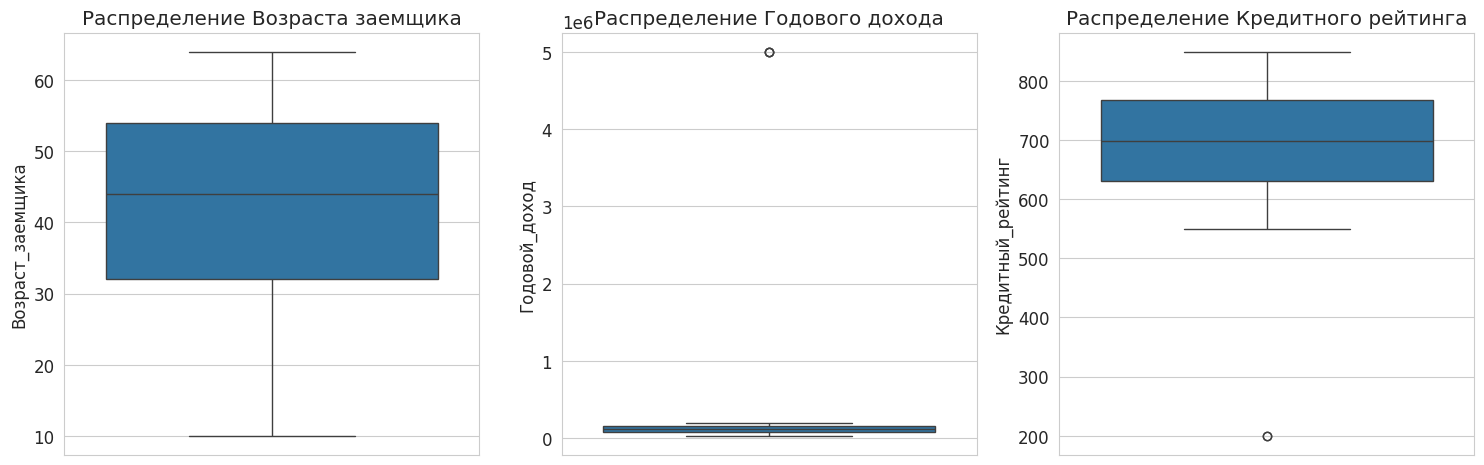

Годовой_доход ограничен от 32078.71 до 198639.06

Статистика некоторых признаков после обработки выбросов:
       Возраст_заемщика  Годовой_доход  Кредитный_рейтинг
count       1000.000000    1000.000000        1000.000000
mean          42.906000  118320.235700         697.813000
std           12.438725   48893.531566          84.200176
min           18.000000   32078.710000         300.000000
25%           32.000000   76369.750000         630.750000
50%           44.000000  117572.500000         698.000000
75%           54.000000  161052.500000         767.250000
max           64.000000  198639.060000         849.000000


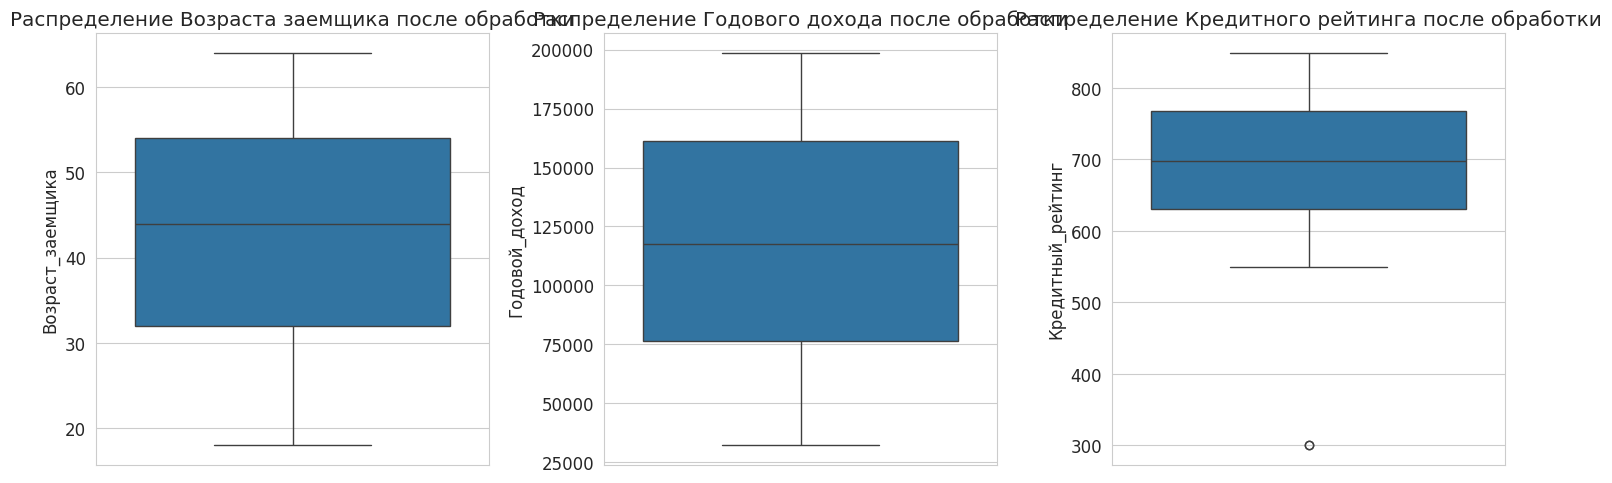


Категориальные признаки: ['Семейное_положение', 'Наличие_других_кредитов', 'Тип_трудоустройства']
Числовые признаки: ['Возраст_заемщика', 'Годовой_доход', 'Кредитный_рейтинг', 'Наличие_детей', 'Стаж_на_текущем_месте_работы_лет', 'Стоимость_недвижимости', 'Первоначальный_взнос_процент']

Размер X_train до кодирования: (750, 10)
Размер X_train после кодирования: (750, 17)

Первые 5 строк X_train после кодирования:
   Возраст_заемщика  Годовой_доход  Кредитный_рейтинг  Наличие_детей  \
0               0.0            0.0                1.0            0.0   
1               0.0            0.0                1.0            0.0   
2               0.0            0.0                0.0            1.0   
3               1.0            0.0                0.0            0.0   
4               1.0            0.0                0.0            0.0   

   Стаж_на_текущем_месте_работы_лет  Стоимость_недвижимости  \
0                               1.0                     0.0   
1                       

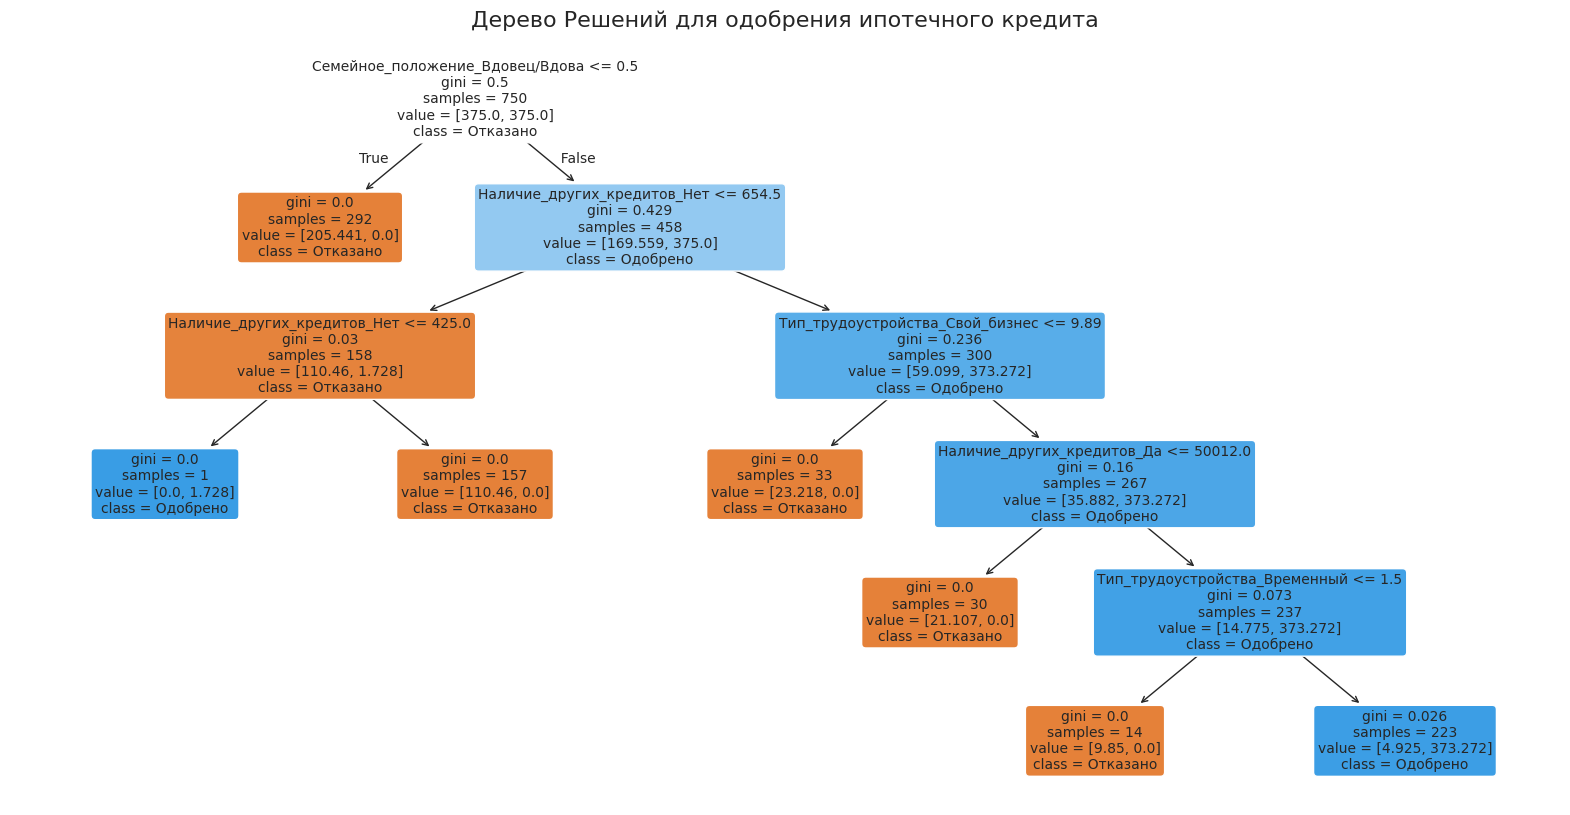


Точность модели на тестовом наборе: 0.9800

Матрица ошибок:
[[175   2]
 [  3  70]]


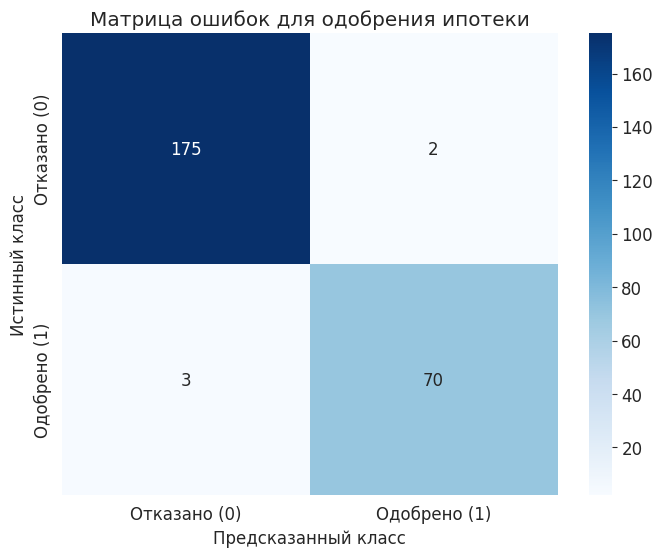


Отчет по классификации:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       177
           1       0.97      0.96      0.97        73

    accuracy                           0.98       250
   macro avg       0.98      0.97      0.98       250
weighted avg       0.98      0.98      0.98       250


Важность признаков (по дереву решений):
                            Признак  Важность
8   Семейное_положение_Вдовец/Вдова  0.387302
12      Наличие_других_кредитов_Нет  0.359957
11       Наличие_других_кредитов_Да  0.101417
16  Тип_трудоустройства_Свой_бизнес  0.100122
14    Тип_трудоустройства_Временный  0.051202
0                  Возраст_заемщика  0.000000
1                     Годовой_доход  0.000000
3                     Наличие_детей  0.000000
2                 Кредитный_рейтинг  0.000000
7      Семейное_положение_В_разводе  0.000000


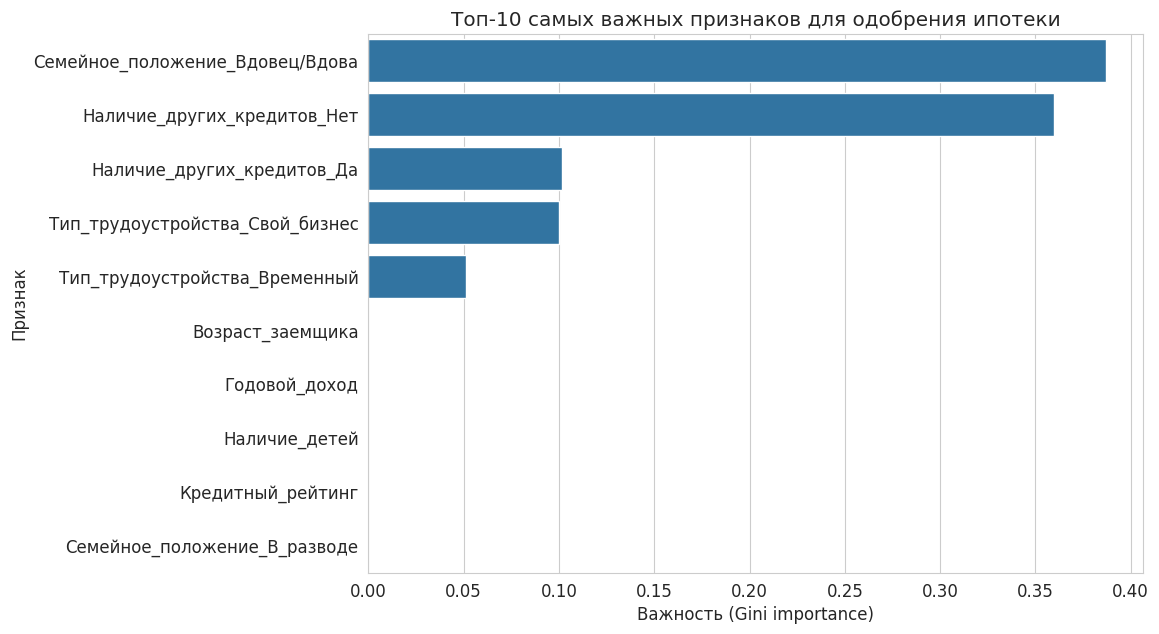

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Настройка стиля для графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

# Создаем синтетические данные для демонстрации
print("Создаем демонстрационные данные для задачи одобрения ипотечного кредита.")
np.random.seed(42) # Для воспроизводимости

data = {
    'ID_Заявки': range(1, 1001),
    'Возраст_заемщика': np.random.randint(22, 65, 1000),
    'Годовой_доход': np.random.randint(30000, 200000, 1000),
    'Кредитный_рейтинг': np.random.randint(550, 850, 1000),
    'Семейное_положение': np.random.choice(['Холост/Не_замужем', 'Женат/Замужем', 'В_разводе', 'Вдовец/Вдова'], 1000, p=[0.3, 0.45, 0.15, 0.1]),
    'Наличие_детей': np.random.randint(0, 4, 1000),
    'Наличие_других_кредитов': np.random.choice(['Да', 'Нет'], 1000, p=[0.4, 0.6]),
    'Стаж_на_текущем_месте_работы_лет': np.random.randint(0, 30, 1000),
    'Тип_трудоустройства': np.random.choice(['Постоянный', 'Временный', 'Свой_бизнес', 'Безработный'], 1000, p=[0.6, 0.15, 0.15, 0.1]),
    'Стоимость_недвижимости': np.random.randint(150000, 800000, 1000),
    'Первоначальный_взнос_процент': np.random.uniform(5.0, 50.0, 1000)
}
df = pd.DataFrame(data)

# Создаем целевую переменную 'Одобрение_кредита' на основе некоторых правил
# (для демонстрации, в реальной жизни это исторические данные)
df['Одобрение_кредита'] = 0 # По умолчанию отказать
df.loc[(df['Кредитный_рейтинг'] > 650) &
       (df['Годовой_доход'] > 50000) &
       (df['Первоначальный_взнос_процент'] >= 10) &
       (df['Тип_трудоустройства'] == 'Постоянный') &
       (df['Стаж_на_текущем_месте_работы_лет'] >= 2), 'Одобрение_кредита'] = 1

# Добавляем пропущенные значения и выбросы для демонстрации
for col in ['Годовой_доход', 'Кредитный_рейтинг', 'Первоначальный_взнос_процент']:
    df.loc[np.random.choice(df.index, 30, replace=False), col] = np.nan # ~3% пропусков
df.loc[np.random.choice(df.index, 5, replace=False), 'Возраст_заемщика'] = 10 # Слишком молод (выброс)
df.loc[np.random.choice(df.index, 2, replace=False), 'Кредитный_рейтинг'] = 200 # Слишком низкий рейтинг
df.loc[np.random.choice(df.index, 3, replace=False), 'Годовой_доход'] = 5000000 # Слишком высокий доход (выброс)

print("\nПервые 5 строк данных:")
print(df.head())
print("\nИнформация о данных:")
df.info()
print("\nКоличество одобрений/отказов:")
print(df['Одобрение_кредита'].value_counts())

print("\nПропущенные значения до обработки:")
print(df.isnull().sum())

# Заполнение пропущенных числовых значений медианой
for col in ['Годовой_доход', 'Кредитный_рейтинг', 'Первоначальный_взнос_процент']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Пропущенные значения в '{col}' заполнены медианой: {median_val:.2f}")

print("\nПропущенные значения после обработки:")
print(df.isnull().sum())

print("\nСтатистика некоторых признаков до обработки выбросов:")
print(df[['Возраст_заемщика', 'Годовой_доход', 'Кредитный_рейтинг']].describe())

# Визуализация выбросов с помощью boxplot
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Возраст_заемщика'])
plt.title('Распределение Возраста заемщика')
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Годовой_доход'])
plt.title('Распределение Годового дохода')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Кредитный_рейтинг'])
plt.title('Распределение Кредитного рейтинга')
plt.tight_layout()
plt.show()

# Ограничение значений (винсоризация / clipping)
# Возраст: разумный диапазон 18-90
df['Возраст_заемщика'] = df['Возраст_заемщика'].clip(lower=18, upper=90)
# Годовой_доход: ограничим 99-м перцентилем сверху и 1-м перцентилем снизу
q_low_income = df['Годовой_доход'].quantile(0.01)
q_high_income = df['Годовой_доход'].quantile(0.99)
df['Годовой_доход'] = df['Годовой_доход'].clip(lower=q_low_income, upper=q_high_income)
print(f"Годовой_доход ограничен от {q_low_income:.2f} до {q_high_income:.2f}")

# Кредитный_рейтинг: разумный диапазон 300-850
df['Кредитный_рейтинг'] = df['Кредитный_рейтинг'].clip(lower=300, upper=850)

print("\nСтатистика некоторых признаков после обработки выбросов:")
print(df[['Возраст_заемщика', 'Годовой_доход', 'Кредитный_рейтинг']].describe())

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Возраст_заемщика'])
plt.title('Распределение Возраста заемщика после обработки')
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Годовой_доход'])
plt.title('Распределение Годового дохода после обработки')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Кредитный_рейтинг'])
plt.title('Распределение Кредитного рейтинга после обработки')
plt.tight_layout()
plt.show()

# Разделение на признаки (X) и целевую переменную (y)
X = df.drop(['ID_Заявки', 'Одобрение_кредита'], axis=1)
y = df['Одобрение_кредита']

# Определяем категориальные и числовые признаки
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=np.number).columns

print(f"\nКатегориальные признаки: {list(categorical_features)}")
print(f"Числовые признаки: {list(numerical_features)}")

# Создаем препроцессор для кодирования категориальных данных
# Для деревьев решений масштабирование числовых данных не требуется
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Оставить числовые колонки как есть
)

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"\nРазмер X_train до кодирования: {X_train.shape}")

# Применяем препроцессор
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Размер X_train после кодирования: {X_train_processed.shape}")

# Получаем имена признаков после One-Hot Encoding
ohe_feature_names = preprocessor.named_transformers_['cat_onehot'].get_feature_names_out(categorical_features)

# Объединяем все имена признаков: сначала числовые, потом One-Hot закодированные
processed_feature_names = list(numerical_features) + list(ohe_feature_names)

# Преобразуем обратно в DataFrame для удобства дальнейшей работы и визуализации
X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=processed_feature_names)

print("\nПервые 5 строк X_train после кодирования:")
print(X_train_processed_df.head())

# Инициализируем и обучаем модель Дерева Решений
# max_depth=5 для лучшей интерпретируемости
decision_tree_model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
# class_weight='balanced' полезно, если классы несбалансированы

logistic_model.fit(X_train_selected, y_train)

decision_tree_model.fit(X_train_processed_df, y_train)

print("\nМодель Дерева Решений успешно обучена.")

plt.figure(figsize=(20, 10))
plot_tree(decision_tree_model,
          feature_names=processed_feature_names,
          class_names=['Отказано', 'Одобрено'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Дерево Решений для одобрения ипотечного кредита', fontsize=16)
plt.show()

# Предсказания на тестовом наборе
y_pred = decision_tree_model.predict(X_test_processed_df)

# Оценка производительности
accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность модели на тестовом наборе: {accuracy:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("\nМатрица ошибок:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Отказано (0)', 'Одобрено (1)'],
            yticklabels=['Отказано (0)', 'Одобрено (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок для одобрения ипотеки')
plt.show()

# Отчет по классификации
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred))

# Важность признаков
feature_importances = pd.DataFrame({'Признак': processed_feature_names,
                                    'Важность': decision_tree_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Важность', ascending=False)
print("\nВажность признаков (по дереву решений):")
print(feature_importances.head(10))

plt.figure(figsize=(10, 7))
sns.barplot(x='Важность', y='Признак', data=feature_importances.head(10))
plt.title('Топ-10 самых важных признаков для одобрения ипотеки')
plt.xlabel('Важность (Gini importance)')
plt.ylabel('Признак')
plt.show()